# Basic AutoEncoder Anomaly Detector with SSIM loss
Loss func: SSIM

In [ ]:
# Download the dataset, setup packages
# SSIM
!pip install torchmetrics
import os
import cv2
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import random

import torch as torch
import torch.nn as nn
import torch.optim as optim
# SSIM addition
from torchmetrics.image import StructuralSimilarityIndexMeasure


if not os.path.exists('dataset.zip'):
  !gdown 1_pRKXtYRjWjY0seYqyx25nOxjtr-mHYg
  !unzip -q -u dataset.zip
else:
  print('Already downloaded')

Already downloaded


In [ ]:
# Some helper functions
def load_dataset(class_name = 'pasta'):
  assert class_name in ['pasta', 'screws', 'capsule']
  dir = './dataset/'+class_name+'/'
  training_images = []
  testing_images = []
  testing_labels = []
  for file_name in os.listdir(dir+'train/good/'):
    training_images.append(cv2.cvtColor(cv2.imread(dir+'train/good/'+file_name), cv2.COLOR_BGR2RGB))
  for file_name in os.listdir(dir+'test/good/'):
    testing_images.append(cv2.cvtColor(cv2.imread(dir+'test/good/'+file_name), cv2.COLOR_BGR2RGB))
    testing_labels.append(0)
  for file_name in os.listdir(dir+'test/bad/'):
    testing_images.append(cv2.cvtColor(cv2.imread(dir+'test/bad/'+file_name), cv2.COLOR_BGR2RGB))
    testing_labels.append(1)

  # returns a normalized (0-1) numpy array of size (n,)
  return np.array(training_images)/255., np.array(testing_images)/255., np.array(testing_labels)

def basic_evaluation(predictions : np.ndarray, targets : np.ndarray):
  print(targets)
  print(predictions)
  print('Accuracy Score: ', accuracy_score(targets, predictions>0.5))
  print('F1 Score: ', f1_score(targets, predictions>0.5))
  print('AUROC Score:', roc_auc_score(targets, predictions))

In [ ]:
def set_seed(seed=77):
    """Locks down all random number generators for reproducibility."""
    # 1. Python built-in random module
    random.seed(seed)

    # 2. NumPy (This fixes your np.random.choice issue!)
    np.random.seed(seed)

    # 3. PyTorch (CPU and GPU)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # 4. CuDNN (GPU backend)
    # Note: Forcing deterministic behavior can slightly slow down training
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Call this immediately!
set_seed(2222)

In [ ]:
# What size to make latent vector dim?
class Encoder(nn.Module):
    def __init__(self, image_height, image_width, latent_vector_dim = 16):
        super().__init__()

        '''
        Encoder has 3 3x3 convolutional layers which reduces dimensions in half each layer (stride = 2). These layers act as feature extractors

        Recall: stride is how many pixels filter slides (produces less outputs for bigger stride). It is 'learned downsampling'.
                In contrast pooling throws away backgroud noise and has no 'learning'
        '''

        self.convolution = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),

            # LeakyReLU(0.2) keeps a small gradient, producing richer feature maps
            nn.LeakyReLU(0.2),
            # Normalises feature maps between layers
            # stabilises training and preventing internal covariate shift
            # 15-20 training images -> gradients are noisy
            nn.InstanceNorm2d(32, affine=True),

            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.InstanceNorm2d(64, affine=True),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.InstanceNorm2d(128, affine=True),

            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.InstanceNorm2d(256, affine=True),
        )

        '''
        To get these values from latent vector, we use fully connected layer to scale down to 1 param (1 meam and 1 variance) (as mean and variance use all values in vector?)
        Options are nn.Linear(input_dim, output_dim) or nn.LazyLinear(output_dim) which does it for you?

        Using linear as we need these values anyways for our decoder. therefore we have to do a dummy pass to see the output shapes
        '''
        dummy_input = torch.zeros(1, 3, image_height, image_width)
        dummy_output = self.convolution(dummy_input)

        # Save this shape for the decoder to use later
        self.flattened_size = dummy_output.view(1, -1).size(1)
        self.spatial_shape = dummy_output.shape[1:]

        self.fc = nn.Linear(self.flattened_size, latent_vector_dim)

        # # fully connected layer
        # self.fully_connected_mu = nn.LazyLinear(latent_vector_dim)
        # # fully connected layer
        # self.fully_connnected_log_var = nn.LazyLinear(latent_vector_dim)

    def forward(self,x):

        # Go through our convolutional layers
        z = self.convolution(x)

        # flatten output into latent vector
        # if doing 1x1x1 convolution you do not flatten you jsut march on

        x = torch.flatten(z, start_dim =1)

        # change to convolutional 1x1x1
        # now we want our flattened vector to pass through both fc layers to yeild 2 parameters which will act as our mean and variance
        latent_vector = self.fc(x)

        return latent_vector


In [ ]:
class Decoder(nn.Module):
    def __init__(self, latent_vector_dim, flattened_size, spatial_shape):
        super().__init__()
        self.spatial_shape = spatial_shape

        self.fully_connected_decoder_in = nn.Linear(latent_vector_dim, flattened_size)

        # decoder mirrors encoder and reverses to reconstruct the spacial resolution
        self.decoder = nn.Sequential(
            nn.Unflatten(1, self.spatial_shape),

            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.InstanceNorm2d(128, affine = True),

            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.InstanceNorm2d(64, affine=True),

            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.InstanceNorm2d(32, affine=True),

            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, z):

        # expand the latent vector into an input big enough for our decoder
        x = self.fully_connected_decoder_in(z)
        output = self.decoder(x)
        return output

In [ ]:
def calc_loss(x, recon_out, ssim_metric):

  ssim_score = ssim_metric(recon_out, x)

  # A perfect reconstruction gives SSIM = 1 . Therefore to make this a loss function we do 1-1.

  reconstruction_loss = 1.0 - ssim_score

  return reconstruction_loss

In [ ]:

class Basic_AE(nn.Module):
  def __init__(self, image_height, image_width, latent_vector_dim = 16, num_epochs=30):
    super().__init__()

    self.encoder = Encoder(image_height, image_width)

    self.decoder = Decoder(latent_vector_dim, self.encoder.flattened_size, self.encoder.spatial_shape)

  def forward(self, x):
    lv = self.encoder(x)
    reconstructed_output = self.decoder(lv)

    return reconstructed_output



In [ ]:
# made with ai
def generate_anomaly_heatmap(original, reconstructed):
    """
    original, reconstructed: tensors of shape (N, C, H, W)
    returns: heatmaps (N, H, W)
    """
    # Pixel-wise squared error
    error = (original - reconstructed) ** 2

    # Collapse RGB → single channel
    heatmap = torch.mean(error, dim=1)  # (N, H, W)

    return heatmap

In [ ]:
# made with AI, not in final version
def visualize_reconstructions(model, test_data, num_images=5):
    """Passes a few test images through the model and plots the original vs. reconstruction."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    # Grab a few random images from the test set
    indices = np.random.choice(len(test_data), num_images, replace=False)
    sample_images = test_data[indices]

    # Convert to PyTorch tensor and fix dimensions for model (N, C, H, W)
    x = torch.tensor(sample_images).permute(0, 3, 1, 2).float().to(device)

    #x = torch.clamp(x, 0., 1.)

    with torch.no_grad():
        reconstructed = model(x)

    heatmaps = generate_anomaly_heatmap(x, reconstructed)
    # Move back to CPU and format for matplotlib (N, H, W, C)
    recon_images = reconstructed.permute(0, 2, 3, 1).cpu().numpy()
    heatmaps = heatmaps.cpu().numpy()


    # Plotting
    fig, axes = plt.subplots(num_images, 3, figsize=(9, 3 * num_images))
    fig.suptitle("Original vs Reconstructed", fontsize=16)

    for i in range(num_images):
        # Original Image
        axes[i, 0].imshow(sample_images[i])
        axes[i, 0].set_title("Original")
        axes[i, 0].axis('off')

        # Reconstructed Image
        axes[i, 1].imshow(recon_images[i])
        axes[i, 1].set_title("Reconstructed")
        axes[i, 1].axis('off')

        # heat map?
        axes[i, 2].imshow(heatmaps[i], cmap = 'hot')
        axes[i, 2].set_title("Heatmap")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
def train_model(model, dataset, num_epochs, learning_rate=1e-3):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # SSIM init ((our image values are 0 to 1))
    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

    # convert numpy to torch, need to rearrange the dimensions
    x = torch.tensor(dataset).permute(0,3,1,2).float().to(device)

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(num_epochs):

      model.train()

      # compute vae forward
      recon_out = model(x)

      # compute loss
      loss = calc_loss(x, recon_out,ssim_metric)

      # clear old gradients from last iter
      optimizer.zero_grad()

      # backward pass for optimization
      loss.backward()

      # update
      optimizer.step()

      print("epoch",epoch,"loss",loss.item())


def predict(model, test_data):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    model.eval()

    x = torch.tensor(test_data).permute(0,3,1,2).float().to(device)

    with torch.no_grad():

      x_hat = model(x)

      errors = torch.mean((x - x_hat)**2, dim=(1,2,3))

    return errors.cpu().numpy()


screws analysis
epoch 0 loss 0.982966423034668
epoch 1 loss 0.9810227155685425
epoch 2 loss 0.9205629825592041
epoch 3 loss 0.8727010488510132
epoch 4 loss 0.8343413472175598
epoch 5 loss 0.803011417388916
epoch 6 loss 0.7769591808319092
epoch 7 loss 0.7535706758499146
epoch 8 loss 0.732108473777771
epoch 9 loss 0.7116365432739258
epoch 10 loss 0.6916950941085815
epoch 11 loss 0.6723004579544067
epoch 12 loss 0.653393566608429
epoch 13 loss 0.6349277496337891
epoch 14 loss 0.617363452911377
epoch 15 loss 0.6010161638259888
epoch 16 loss 0.5861002206802368
epoch 17 loss 0.5725193023681641
epoch 18 loss 0.5600852966308594
epoch 19 loss 0.5486447811126709
epoch 20 loss 0.5382041335105896
epoch 21 loss 0.5287145972251892
epoch 22 loss 0.5200644135475159
epoch 23 loss 0.512118935585022
epoch 24 loss 0.5047180652618408
epoch 25 loss 0.4977586269378662
epoch 26 loss 0.49121952056884766
epoch 27 loss 0.4850895404815674
epoch 28 loss 0.47937679290771484
epoch 29 loss 0.47403883934020996
[0 0 0 

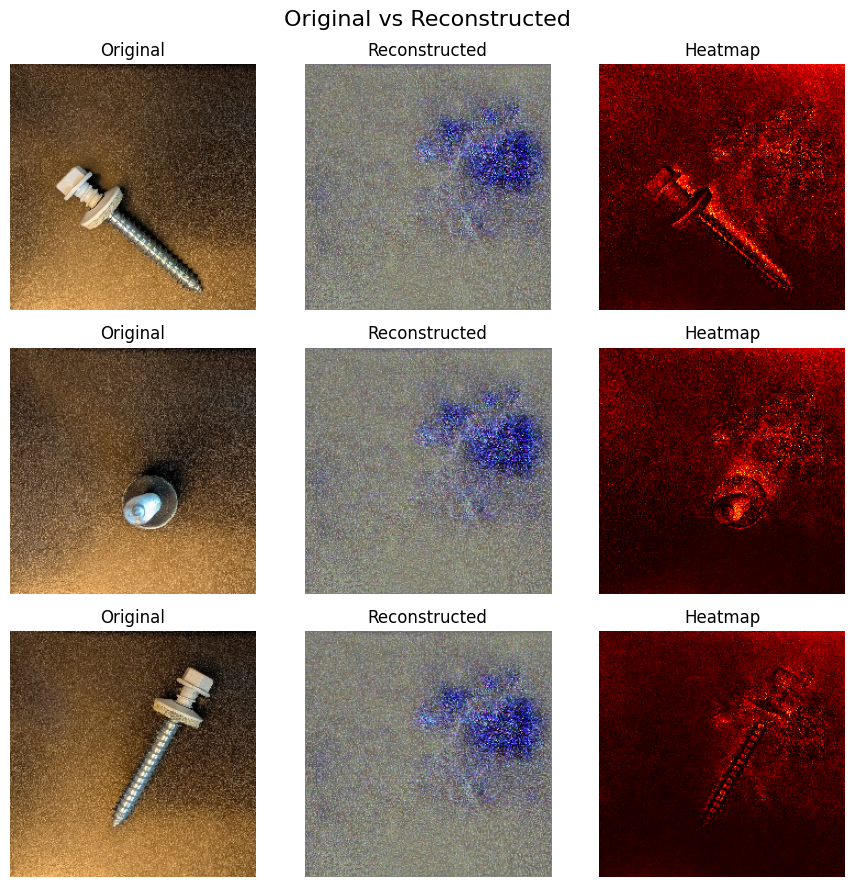

pasta analysis
epoch 0 loss 0.9821837544441223
epoch 1 loss 0.978427529335022
epoch 2 loss 0.9642279148101807
epoch 3 loss 0.9483703374862671
epoch 4 loss 0.9318626523017883
epoch 5 loss 0.9143185615539551
epoch 6 loss 0.8960863351821899
epoch 7 loss 0.8773487210273743
epoch 8 loss 0.8578678369522095
epoch 9 loss 0.8379230499267578
epoch 10 loss 0.817857563495636
epoch 11 loss 0.7975850701332092
epoch 12 loss 0.7770445346832275
epoch 13 loss 0.7562459707260132
epoch 14 loss 0.7349650859832764
epoch 15 loss 0.7128642201423645
epoch 16 loss 0.6895869970321655
epoch 17 loss 0.6649195551872253
epoch 18 loss 0.6391890645027161
epoch 19 loss 0.6134121417999268
epoch 20 loss 0.5898405313491821
epoch 21 loss 0.5694124698638916
epoch 22 loss 0.551683783531189
epoch 23 loss 0.5347731709480286
epoch 24 loss 0.5186645984649658
epoch 25 loss 0.5037504434585571
epoch 26 loss 0.49033135175704956
epoch 27 loss 0.47768956422805786
epoch 28 loss 0.46623581647872925
epoch 29 loss 0.45628511905670166
[0 0

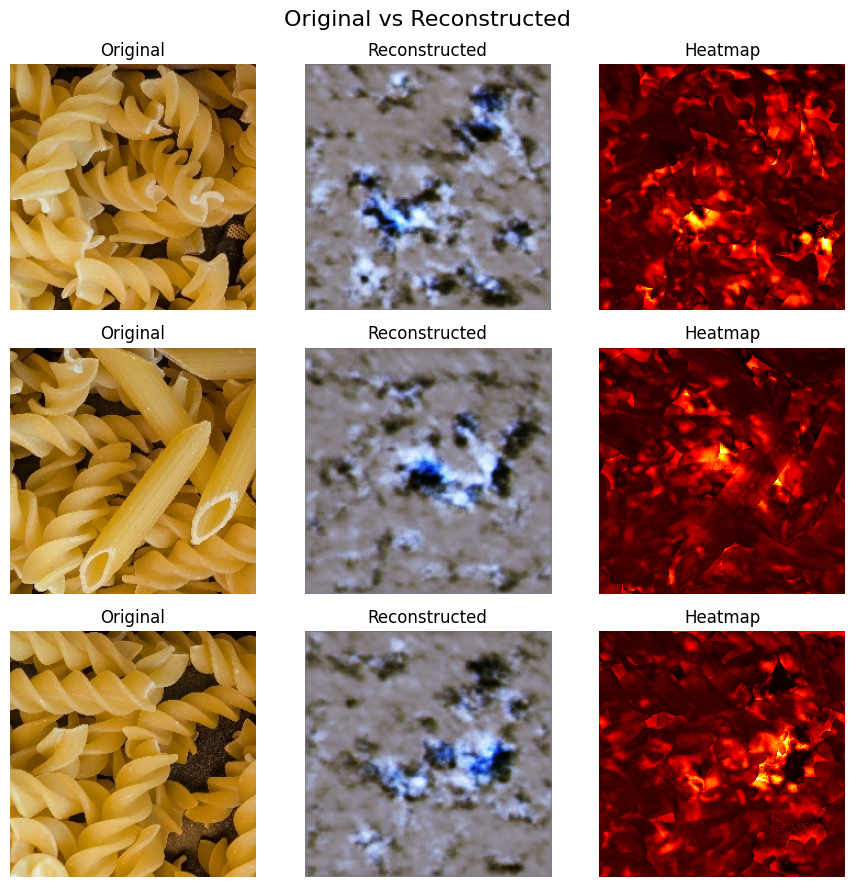

capsule analysis
epoch 0 loss 0.9789856672286987
epoch 1 loss 0.9778757691383362
epoch 2 loss 0.9649396538734436
epoch 3 loss 0.9503185153007507
epoch 4 loss 0.9318684339523315
epoch 5 loss 0.9089998006820679
epoch 6 loss 0.8797733187675476
epoch 7 loss 0.8449990749359131
epoch 8 loss 0.8059641122817993
epoch 9 loss 0.7468602061271667
epoch 10 loss 0.6980807781219482
epoch 11 loss 0.630411684513092
epoch 12 loss 0.5773102045059204
epoch 13 loss 0.5314865112304688
epoch 14 loss 0.48057395219802856
epoch 15 loss 0.4445112347602844
epoch 16 loss 0.41792958974838257
epoch 17 loss 0.3905488848686218
epoch 18 loss 0.3773707151412964
epoch 19 loss 0.36465299129486084
epoch 20 loss 0.3537369966506958
epoch 21 loss 0.3454720377922058
epoch 22 loss 0.33931028842926025
epoch 23 loss 0.3329053521156311
epoch 24 loss 0.3278502821922302
epoch 25 loss 0.32306212186813354
epoch 26 loss 0.31850486993789673
epoch 27 loss 0.3151646852493286
epoch 28 loss 0.3108200430870056
epoch 29 loss 0.306564152240753

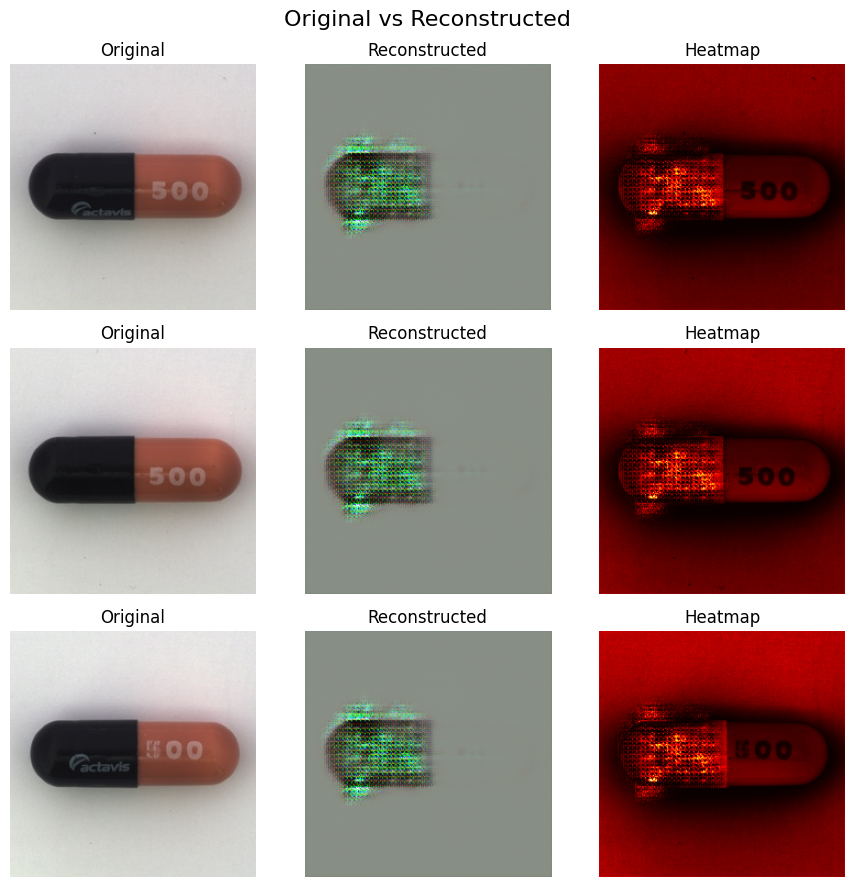

In [ ]:
# TODO use class above as well as helper functions to generate
# predictions on the datasets and evaluate the results.

def do_analysis(class_name):

  training_images, testing_images, testing_labels = load_dataset(class_name=class_name)

  img_height = training_images.shape[1]
  img_width = training_images.shape[2]

  basic_model = Basic_AE(img_height, img_width)

  train_model(basic_model, training_images, num_epochs=30)

  predictions = predict(basic_model, testing_images)
  basic_evaluation(predictions, testing_labels)
  visualize_reconstructions(basic_model, testing_images, num_images=3)

print("screws analysis")
do_analysis('screws')
print("pasta analysis")
do_analysis('pasta')
print("capsule analysis")
do_analysis('capsule')
